In [1]:
import torch
import torchvision

from torch import cuda
from torch.nn.functional import nll_loss, log_softmax

from utils.progress import progressbar as pgb

FILES_DIR = './files/'

n_epochs = 50
batch_size_train = 64
batch_size_test = 1000
learning_rate = 0.01
momentum = 0.5

random_seed = 1
torch.backends.cudnn.enabled = False
torch.manual_seed(random_seed)

#print(torch.cuda.get_device_name(0))
device = torch.device("cuda" if cuda.is_available() else "cpu")
print(f'{torch.__version__=}')
print(f'{torch.version.cuda=}')
print(f'{cuda.is_available()=}')
print(f'{cuda.device_count()=}')
print(f'{cuda.get_device_name(torch.cuda.current_device())=}')


torch.__version__='2.11.0+cu130'
torch.version.cuda='13.0'
cuda.is_available()=True
cuda.device_count()=1
cuda.get_device_name(torch.cuda.current_device())='NVIDIA GeForce RTX 5070'


## Model

In [2]:
class TwoLayerNet(torch.nn.Module):
    def __init__(self, D_in, H, D_out):
        """
        In the constructor we instantiate two nn.Linear modules and assign them as
        member variables.
        """
        super(TwoLayerNet, self).__init__()
        self.linear1 = torch.nn.Linear(D_in, H)
        self.linear2 = torch.nn.Linear(H, D_out)

    def forward(self, x):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary (differentiable) operations on Tensors.
        """
        h_relu = self.linear1(x).clamp(min=0)
        y_pred = log_softmax(self.linear2(h_relu), dim=1)

        return y_pred


## Data

In [4]:
# dimension IN, input layer
D_in = 28 * 28
# neurons in hidden layer
H = 100
# dimension OUT, output layer
D_out = 10 # classes in MNIST

# Create random Tensors to hold inputs and outputs
def get_random_batch(size=batch_size_train, dim_in=D_in, num_classes=D_out):
    x = torch.randn(size, dim_in)
    y = torch.randint(0, num_classes, size=(size,))
    assert len(x) == len(y)
    return x, y

def dummy_loader(batch_size=batch_size_train, batch_count=10,  dim_in=D_in, num_classes=D_out):
    for _ in range(batch_count):
        yield get_random_batch(size=batch_size, dim_in=dim_in, num_classes=num_classes)

torch.Size([64, 784])

In [ ]:
train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(FILES_DIR, train=True, download=True,
                               transform=torchvision.transforms.Compose([
                                   torchvision.transforms.ToTensor(),
                                   torchvision.transforms.Normalize(
                                       (0.1307,), (0.3081,))
                               ])),
    batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(FILES_DIR, train=False, download=True,
                               transform=torchvision.transforms.Compose([
                                   torchvision.transforms.ToTensor(),
                                   torchvision.transforms.Normalize(
                                       (0.1307,), (0.3081,))
                               ])),
    batch_size=batch_size_test, shuffle=True)

## Training

In [5]:
# Construct our model by instantiating the class defined above.
model = TwoLayerNet(D_in, H, D_out).to(device)
loss_fn = nll_loss
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)
batch_count = len(train_loader) # for progressbar only

# Training
train_losses = []
for t in pgb(range(n_epochs), n_epochs):
    # for batch_idx, (data, target) in enumerate(get_random_batch(size=N, dim_in=D_in, num_classes=D_out)):
    loss = 0
    for batch_idx, (data, target) in pgb(enumerate(train_loader), batch_count, cleanup=True):
        data = torch.flatten(data, start_dim=1) # Flatten images
        x = data.to(device)
        y_target = target.to(device)
        # Forward pass: Compute predicted y by passing x to the model
        y_pred = model(x)
        # Compute and print loss
        loss = loss_fn(y_pred, y_target)
        # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item()) # Add most recent loss after batch

Output()

In [10]:
# torch.save(model.state_dict(), './results/model.pth')
# torch.save(optimizer.state_dict(), './results/optimizer.pth')

## Plot results

Text(0, 0.5, 'negative log likelihood loss')

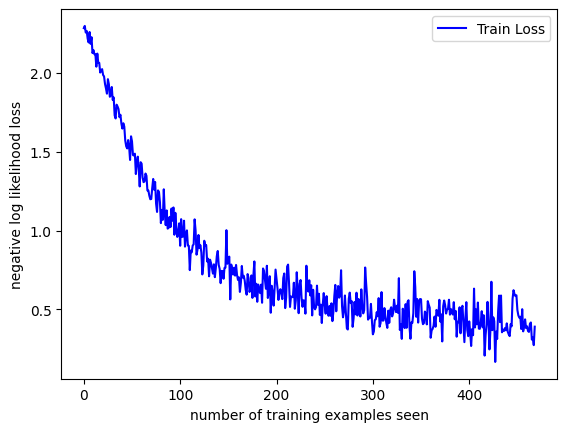

In [7]:
import matplotlib.pyplot as plt

fig = plt.figure()
epoch_losses = train_losses[::100]
plt.plot(range(len(epoch_losses)), epoch_losses, color='blue')
plt.legend(['Train Loss'], loc='upper right')
plt.xlabel('number of training examples seen')
plt.ylabel('negative log likelihood loss')